In [ ]:

from sklearn.utils import Bunch
import pandas as pd

# 1. 準備你的檔案路徑 (這裡請替換成你電腦裡真實的檔案路徑字串)
# 注意：即使只有一個受試者，也請把它放在 List (中括號 []) 裡面
my_func_files = ['/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/NTUSEC008/nii/ses01/REST_SES01/results/residuals_epi1.nii.gz']
my_confound_files = ['/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/NTUSEC008/nii/ses01/REST_SES01/multiple_regressors_epi1.txt']

# 2. 準備受試者資料 (Phenotypic data)
# 使用 Pandas DataFrame 來建立表格是最清楚的做法
pheno_df =  ['NONE']

# 3. 設定重複時間 TR (Repetition Time)
# 也就是 fMRI 機器每隔幾秒拍一張完整的 3D 腦部影像
my_t_r = 2.0 

# 4. 把所有東西組裝成 Bunch 物件！
func_data = Bunch(
    func=my_func_files,
    confounds=my_confound_files,
    phenotypic=pheno_df,
    description="這是我自己手動包裝的 fMRI 資料集",
    t_r=my_t_r
)

fmri_filepath = func_data.func[0]

In [ ]:
from nilearn.input_data import NiftiMasker

masker = NiftiMasker()
masked_data = masker.fit_transform(fmri_filepath, confounds=func_data.confounds)
masked_data.shape

In [ ]:
thresholded_masked_data = masked_data * (masked_data > masked_data.mean())
thresholded_img = masker.inverse_transform(thresholded_masked_data)


## MY ATLAS

In [ ]:
import pandas as pd
from nilearn.maskers import NiftiLabelsMasker


atlas_filepath = '/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/NTUSEC008/nii/ses01/T1/ROIROI/wSSTAAL3v1.nii'
label_filepath = '/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/FOR_BHS/AAL3/AAL3v1.nii.txt'


labels = ['Background'] 

with open(label_filepath, 'r', encoding='utf-8') as f:
    for line in f:
        # 移除換行符號並根據空格或 Tab 切割
        parts = line.strip().split()
        
        # 假設 AAL 的 txt 格式是 "1 Precentral_L" 這種形式
        if len(parts) >= 2:
            # 抓取腦區名稱 (通常是英文縮寫，例如 Precentral_L)
            region_name = parts[1] 
            labels.append(region_name)
        elif len(parts) == 1:
            # 如果每一行只有一個名字
            labels.append(parts[0])



masker = NiftiLabelsMasker(
    labels_img=atlas_filepath, 
    labels=labels, 
)

import nibabel as nib

fmri_img = nib.load(fmri_filepath)
time_series = masker.fit_transform(fmri_img)
print(time_series.shape) 

總共載入了 171 個標籤 (包含 Background)


/tmp/ipykernel_3069732/4198535346.py:43: UserWarning: Too many names for the indices. Dropping excess names values.
  time_series = masker.fit_transform(fmri_img)
/tmp/ipykernel_3069732/4198535346.py:43: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.uint8(160), np.uint8(134), np.uint8(159)}. Label image only contains 164 labels (including background).
  time_series = masker.fit_transform(fmri_img)


(260, 163)


In [ ]:
# import nibabel as nib
# import numpy as np

# # 1. 載入你的 Atlas 影像 (請換成你實際使用的 atlas 路徑)
# atlas_img = nib.load(atlas_filepath)

# # 2. 取得 3D 陣列資料
# atlas_data = atlas_img.get_fdata()

# # 3. 找出所有獨特的數值，並轉為整數格式
# unique_values = np.unique(atlas_data).astype(int)

# # 4. 排除 0 (Background)
# present_labels = unique_values[unique_values != 0]

# print(f"Atlas 影像中實際包含的腦區數值 (共 {len(present_labels)} 個):")
# print(present_labels)

Atlas 影像中實際包含的腦區數值 (共 166 個):
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  37  38
  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56
  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74
  75  76  77  78  79  80  83  84  85  86  87  88  89  90  91  92  93  94
  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112
 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130
 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148
 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166
 167 168 169 170]


In [ ]:
# import nibabel as nib
# import numpy as np

# # 1. 讀取你的 NIfTI 圖譜影像
# atlas_img = nib.load(atlas_filepath)
# atlas_data = atlas_img.get_fdata()

# # 2. 獲取影像中所有實際存在的唯一整數值 (轉為整數以防有小數)
# unique_values = np.unique(atlas_data).astype(int)
# print(f"影像中實際存在的獨立數值數量 (包含背景 0): {len(unique_values)}")

# # 3. 比對遺失的標籤
# # 假設 AAL3 的標籤是連續的 1 到 170
# expected_indices = set(range(1, 171)) 
# actual_indices = set(unique_values) - {0} # 扣除背景 0

# missing_indices = expected_indices - actual_indices
# print(f"遺失的標籤索引 ID: {missing_indices}")

# # 4. 印出遺失的腦區名稱
# print("\n--- 遺失的腦區清單 ---")
# for idx in missing_indices:
#     # 這裡的 idx 剛好對應你 labels 列表的 index (因為你在 index 0 放了 Background)
#     if idx < len(labels):
#         print(f"ID {idx}: {labels[idx]}")

In [ ]:
# # masker.labels_ 會輸出像這樣: [1, 2, 3, 5, 6, ... 162] (注意: 裡面可能沒有 4)
# # 將它們轉為整數列表
# kept_ids = [int(i) for i in masker.labels_]

# labels_161 = []
# for region_id in kept_ids:
#     # 扣除背景(0)。只有大於 0 的 ID 才是有效腦區
#     if region_id > 0:
#         # 因為 Python 索引從 0 開始，所以編號要減 1
#         correct_name = labels[region_id - 1] 
#         labels_161.append(correct_name)

# print(f"成功對齊的標籤數量: {len(labels_161)}")
# # 現在你可以把這個 labels_161 拿去畫 plot_matrix 了！

In [4]:
from nilearn.maskers import NiftiLabelsMasker

# 改用 NiftiLabelsMasker，並注意參數名稱是 labels_img
atlas_masker = NiftiLabelsMasker(labels_img=atlas_filepath)

data_in_atlas = atlas_masker.fit_transform(fmri_filepath)
print(data_in_atlas.shape)

/tmp/ipykernel_3069732/644681883.py:6: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.uint8(160), np.uint8(134), np.uint8(159)}. Label image only contains 164 labels (including background).
  data_in_atlas = atlas_masker.fit_transform(fmri_filepath)


(260, 163)


**Note**: Depending on the type of atlas you use, you might have to use different kinds of masker. Here we have probabilistic overlapping regions, so we use a `NiftiMapsMasker`, but if we had non-overlapping regions, we would use a `NiftiLabelsMasker`.

## Connectome

Let's compute and plot a correlation matrix !

In [ ]:
from nilearn.connectome import ConnectivityMeasure
correlation_measure = ConnectivityMeasure(kind='correlation')
correlation_matrix = correlation_measure.fit_transform([data_in_atlas])[0]



# Plot the correlation matrix
import numpy as np
from nilearn import plotting
# Make a large figure
# Mask the main diagonal for visualization:
np.fill_diagonal(correlation_matrix, 0)
correlation_matrix.shape

/tmp/ipykernel_3069732/642103527.py:3: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  correlation_matrix = correlation_measure.fit_transform([data_in_atlas])[0]


(163, 163)

In [13]:
import numpy as np
import pandas as pd

# ==========================================
# 1. 直接從 Masker 獲取最終保留的 163 個標籤數值
# ==========================================
# 取出數值並確保它們是整數型態
final_labels_163 = np.array(masker.labels_).astype(int)

print(f"✅ Masker 實際輸出的序列數量: {len(final_labels_163)}")

# ==========================================
# 2. 抓出兇手：哪 3 個腦區被 fMRI 遮罩丟掉了？
# ==========================================
# 假設 present_labels 是你上一步用 np.unique 找出的 166 個數值
lost_labels = set(present_labels) - set(final_labels_163)

print(f"❌ 在 fMRI 萃取過程中失去訊號的標籤數值: {lost_labels}")
if len(lost_labels) > 0:
    lost_names = [labels[val] for val in lost_labels]
    print(f"   對應的腦區名稱: {lost_names}")

# ==========================================
# 3. 產生 163x163 矩陣的正確標籤列表
# ==========================================
# 假設 labels 是你一開始讀取的 AAL3 txt 列表 (171 個元素，idx 0 是 Background)
final_region_names_163 = [labels[val] for val in final_labels_163]

# 確認這 163 個名稱正確無誤
# print("這 163 個腦區的名稱:", final_region_names_163)

✅ Masker 實際輸出的序列數量: 164
❌ 在 fMRI 萃取過程中失去訊號的標籤數值: {np.int64(160), np.int64(134), np.int64(159)}
   對應的腦區名稱: ['VTA_R', 'Thal_Re_R', 'VTA_L']


In [ ]:
import numpy as np
import pandas as pd


raw_labels_from_masker = np.array(masker.labels_).astype(int)

# 關鍵修正：強制排除 0 (Background)
final_labels = raw_labels_from_masker[raw_labels_from_masker != 0]

print(f"✅ Masker 實際保留的有效腦區數量: {len(final_labels)}") 
# 這裡預期會是 162 或 163 (取決於你的 fMRI mask)

# ==========================================
# 2. 確認我們提取的 correlation_matrix 大小是否吻合
# ==========================================
num_extracted_regions = len(final_labels)

# # correlation_matrix 是你用 fit_transform 算出來的矩陣
# if correlation_matrix.shape[0] != num_extracted_regions:
#     print(f"⚠️ 警告: 矩陣大小 ({correlation_matrix.shape[0]}) 與標籤數量 ({num_extracted_regions}) 不吻合！")
#     print("這通常代表你在初始化 ConnectivityMeasure 或 NiftiLabelsMasker 時有其他設定介入。")
# else:
#     print("✅ 矩陣大小與標籤數量吻合，準備填入全矩陣。")

# ==========================================
# 3. 填入 171x171 的大矩陣
# ==========================================
num_total_labels = 171 
full_correlation_matrix = np.zeros((num_total_labels, num_total_labels))

# 使用我們過濾後的真實腦區數值當作座標
row_indices, col_indices = np.ix_(final_labels, final_labels)

# 把你的相關矩陣精準填入！
# (前提是 correlation_matrix.shape 必須等於 len(final_labels) x len(final_labels))
full_correlation_matrix[row_indices, col_indices] = correlation_matrix

# ==========================================
# 4. 存檔
# ==========================================
# 假設 labels 是你一開始讀取的 AAL3 txt 列表 (171 個元素，idx 0 是 Background)
df_full_matrix = pd.DataFrame(
    full_correlation_matrix, 
    index=labels,      
    columns=labels   
)

df_full_matrix.to_csv('roiroi_correlation_matrix_171.csv', encoding='utf-8')
print("✅ 已成功儲存 171x171 的完整相關矩陣！")

✅ Masker 實際保留的有效腦區數量: 163
✅ 矩陣大小與標籤數量吻合，準備填入全矩陣。
✅ 已成功儲存 171x171 的完整相關矩陣！


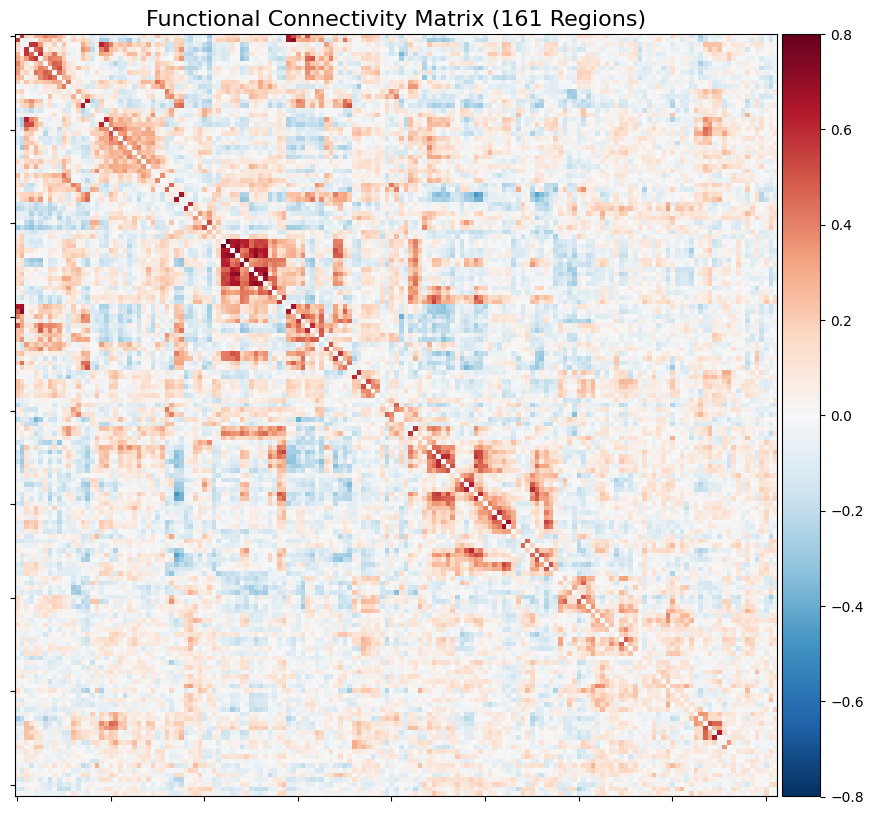

In [7]:
import numpy as np
from nilearn import plotting
import matplotlib.pyplot as plt

# 確認你的矩陣對角線已經歸零
np.fill_diagonal(correlation_matrix, 0)


# 使用 nilearn.plotting.plot_matrix 繪製矩陣
display = plotting.plot_matrix(
    correlation_matrix,
    # labels=labels_161,         # 放入我們剛才正確提取的 161 個腦區標籤
    figure=(10, 8),            # 設定圖片尺寸 (寬, 高)，標籤多時可設大一點如 (12, 10)
    vmax=0.8, vmin=-0.8,       # 設定顏色條的最大/最小範圍，避免極端值吃掉顏色對比 (可自行調整)
    reorder=False,             # 是否將相關性高的腦區自動聚類排在一起 (如果想看特定群集，可設為 True)
    colorbar=True,             # 顯示旁邊的數值顏色條
    title="Functional Connectivity Matrix (161 Regions)"
)

# 顯示圖片 (如果你是在 Jupyter Notebook 中，通常不用加這行也會自動顯示)
plt.show()

In [ ]:
from nilearn.connectome import ConnectivityMeasure
correlation_measure = ConnectivityMeasure(kind='correlation')
correlation_matrix = correlation_measure.fit_transform([data_in_atlas])[0]

# Plot the correlation matrix
import numpy as np
from nilearn import plotting

# Make a large figure
# Mask the main diagonal for visualization:
np.fill_diagonal(correlation_matrix, 0)

# ==========================================
# ⚠️ 關鍵修改：改用 masker 過濾後的標籤
# ==========================================
# 只要你一開始定義 masker 時有傳入 labels=labels，
# masker.labels_ 就會儲存真正有提取到訊號的那 161 個腦區名稱。
labels_for_plot = masker.labels_  
labels_for_plot


# # The matrix is reordered for block-like representation
# plotting.plot_matrix(correlation_matrix, 
#                      figure=(10, 8), 
#                      labels=labels_for_plot,  # 使用新的 labels_for_plot
#                      vmax=0.8, 
#                      vmin=-0.8, 
#                      reorder=True)

## Plotting

Earlier we simply plotted a slice of our brain with matplotlib. It works and it is a fine way to check your data array. However for more complex or fancy plots, nilearn comes with a lot of handy tools in its `nilearn.plotting` module. Here are a few examples.

* To view a 3D NiftiImage object, the `view_img` functions makes it easy to interactively go through the slices.

In [ ]:
from nilearn.plotting import view_img

# Since our fmri_img is a 4D NiftiImage, we need to generate a 3D one.
# One way of doing that is averaging our volumes on the time axis 
# with the mean_img function.
from nilearn.image.image import mean_img

fmri_img_mean = mean_img(fmri_img)
view_img(fmri_img_mean)




In [ ]:
from nilearn.plotting import view_img

# Since our fmri_img is a 4D NiftiImage, we need to generate a 3D one.
# One way of doing that is averaging our volumes on the time axis 
# with the mean_img function.
from nilearn.image.image import mean_img

# fmri_img_mean = mean_img(fmri_img)
# view_img(fmri_img_mean)

# 指定受試者的 T1 影像路徑
subject_t1_path = '/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/FOR_BHS/NTUSEC008/nii/ses01/T1/T1_t1_mprage_sag_p2_iso_20220304142158_2.nii'

# 將 T1 影像設為底圖
view_img(fmri_img_mean, bg_img=subject_t1_path)


* To display the graph corresponding to a connectome, you can use `plot_connectome`.

In [ ]:
from nilearn.plotting import plot_epi

# 直接畫出 fMRI 的平均圖 (不要疊加在標準模板上)
plot_epi(fmri_img_mean, title="Mean fMRI Image (No Template)")

In [ ]:
from nilearn.plotting import plot_connectome

coords = atlas_dataset.region_coords

# We threshold to keep only the 10% of edges with the highest value
# because the graph is very dense
plot_connectome(correlation_matrix, coords,
                edge_threshold="97%", colorbar=True)

## Setup enviroment

In [ ]:
# !pip install -q nilearn

from nilearn import datasets
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
from nilearn import plotting
from nilearn.connectome import ConnectivityMeasure
from nilearn.image import index_img

Save data

In [ ]:
data_dir = None # change this variable with the path where you want nilearn to download
                # the data, if you leave None, the default will be '~/nilearn_data'

# Loading the functional datasets
data = datasets.fetch_development_fmri(n_subjects=1, data_dir=data_dir)

# you can use the .keys() method to check what's in the dataset
data.keys()

Data path

In [ ]:
fmri_filepath = data.func[0]
print(fmri_filepath)

load fmri_img

In [ ]:
fmri_img = nib.load(fmri_filepath)

atlas dataset

In [ ]:
atlas_dataset = datasets.fetch_atlas_msdl(data_dir=data_dir)
atlas_filepath = atlas_dataset.maps
labels = atlas_dataset.labels

NiftiMapsMasker

In [ ]:
from nilearn.input_data import NiftiMapsMasker

atlas_masker = NiftiMapsMasker(maps_img=atlas_filepath, standardize=True)

data_in_atlas = atlas_masker.fit_transform(fmri_filepath, confounds=data.confounds)
data_in_atlas.shape

Connectome measure

In [ ]:
from nilearn.connectome import ConnectivityMeasure
correlation_measure = ConnectivityMeasure(kind='correlation')
correlation_matrix = correlation_measure.fit_transform([data_in_atlas])[0]


# Exercises

## 1. Of the importance of confounds

* Generate a correlation matrix with the same data, but this time without using the confounds when masking.

How does that impact the correlation matrix ?
Why do you think it affects the matrix this way ?

* Plot the obtained connectome in 3D using `nilearn.plotting.view_connectome` (check [the doc](https://nilearn.github.io/modules/generated/nilearn.plotting.view_connectome.html) to know how to use it).

In [ ]:
# as example
atlas_masker_nocon = NiftiMapsMasker(maps_img=atlas_filepath, standardize=True)
data_nocon = atlas_masker_nocon.fit_transform(fmri_filepath)

correlation_measure = ConnectivityMeasure(kind='correlation')
matrix_nocon = correlation_measure.fit_transform([data_nocon])[0]

# take a look at matrix_nocon
plotting.plot_matrix(matrix_nocon, figure=(10, 8), labels=labels, reorder=True)



# plot = plotting.plot_matrix(matrix_nocon, colorbar=True, title="Functional connectivity matrix without confounds")
# plot

In [ ]:
plotting.plot_connectome(matrix_nocon, atlas_dataset.region_coords, title="Ex 1: Connectome WITHOUT Confounds")

## 2. Visualizing the atlas and a specific time point

* Use `view_img` to visualize the 5th ROI of the atlas. (Hint: use the atlas masker to inverse transform an array with 1 at the index 4 and 0 every where else.)

* Use `plotting.plot_prob_atlas` to show all the ROIs with filled contours. (Hint: check the nilearn documentation to see how to use `plotting.plot_prob_atlas`).
* Earlier we used `view_img` to plot the mean volume of our `fmri_img` data because `view_img` doesn't accept 4D images but only 3D ones. Find a way to generate a 3D Nifti image with the 84th time point in `fmri_img` and plot it with `view_img`.

In [ ]:
from nilearn.plotting import view_img

roi_array = np.zeros(len(atlas_dataset.labels))
roi_array[4] = 1
roi_5_img = atlas_masker.inverse_transform(roi_array)

view_img(roi_5_img)

In [ ]:
plotting.plot_prob_atlas(atlas_filepath, title="show all the ROIs")

In [ ]:
Xth_Volume = 84 # @param {type:"integer"}
img_Xth = index_img(fmri_img, Xth_Volume-1)

view_Xth = plotting.view_img(img_Xth, title=f"Volume {Xth_Volume}")
view_Xth

## 3. Seed-based connectivity

*Using the information provided in [this nilearn tutorial](https://nilearn.github.io/stable/auto_examples/03_connectivity/plot_seed_to_voxel_correlation.html), plot the seed-to-voxel correlation map of our fmri_img for the seed of coordinates (-16, -74, 7) and with a sphere mask of radius of size 10.

In [ ]:
from nilearn.maskers import NiftiSpheresMasker
from nilearn.input_data import NiftiMasker

In [ ]:
seed = [(-16, -74, 7)]
seed_nsmasker = NiftiSpheresMasker(seed, radius=4.5, standardize=True)
seed_time_series = seed_nsmasker.fit_transform(fmri_filepath, confounds=data.confounds)

brain_masker = NiftiMasker(standardize=True)
brain_time_series = brain_masker.fit_transform(fmri_filepath, confounds=data.confounds)

seed_to_voxel_correlations = (np.dot(brain_time_series.T, seed_time_series) / seed_time_series.shape[0])
seed_to_voxel_correlations_img = brain_masker.inverse_transform(seed_to_voxel_correlations.T)

threshold = 0.5
plotting.plot_stat_map(seed_to_voxel_correlations_img, threshold=threshold, title=f"Seed based correlation {seed}\nThreshold= {threshold}")
plt.show()